In [9]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

In [10]:
df = pd.read_csv(
    "customer_churn.csv"
)

In [11]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [12]:
df.shape

(440833, 12)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 48.5 MB


In [14]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [15]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [17]:
df.drop("CustomerID", axis=1, inplace=True, errors="ignore")

In [19]:
df["Total Spend"] = pd.to_numeric(
    df["Total Spend"],
    errors="coerce"
)

In [20]:
df.dropna(
    inplace=True
)

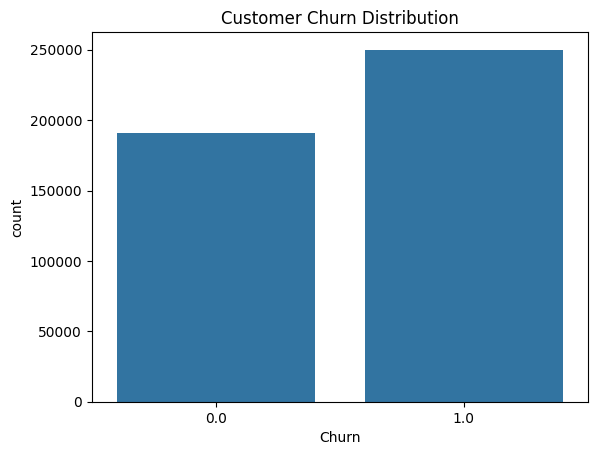

In [22]:
sns.countplot(
    x="Churn",
    data=df
)


plt.title(
    "Customer Churn Distribution"
)


plt.show()




In [23]:
df["Churn"] = df["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)


In [33]:
# 1. Reload the dataset to restore original data
df = pd.read_csv("customer_churn.csv")

# 2. Drop CustomerID if present
df.drop("CustomerID", axis=1, inplace=True, errors="ignore")

# 3. Clean missing values (drops the single NaN row in your original dataset)
df.dropna(inplace=True)

# 4. Encode categorical variables
encoder = LabelEncoder()
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    df[col] = encoder.fit_transform(df[col].astype(str))

# 5. Features & Target split
X = df.drop("Churn", axis=1)
y = df["Churn"]

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
print(
    "Training Data Shape:",
    X_train.shape
)


print(
    "Testing Data Shape:",
    X_test.shape
)


print(
    "Target Training Shape:",
    y_train.shape
)


print(
    "Target Testing Shape:",
    y_test.shape
)


Training Data Shape: (352665, 10)
Testing Data Shape: (88167, 10)
Target Training Shape: (352665,)
Target Testing Shape: (88167,)


In [35]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [36]:
model = Sequential()

In [37]:
model.add(

    Dense(

        units=32,

        activation="relu",

        input_shape=(X_train.shape[1],)

    )

)



C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:

model.add(

    Dropout(

        rate=0.20

    )

)

In [39]:
model.add(

    Dense(

        units=16,

        activation="relu"

    )

)


In [40]:
model.add(

    Dense(

        units=1,

        activation="sigmoid"

    )

)

In [41]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [43]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [44]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.20,

    epochs=50,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9566 - loss: 0.1132 - val_accuracy: 0.9926 - val_loss: 0.0297
Epoch 2/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9912 - loss: 0.0325 - val_accuracy: 0.9947 - val_loss: 0.0234
Epoch 3/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9934 - loss: 0.0260 - val_accuracy: 0.9959 - val_loss: 0.0182
Epoch 4/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9941 - loss: 0.0229 - val_accuracy: 0.9962 - val_loss: 0.0165
Epoch 5/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9944 - loss: 0.0223 - val_accuracy: 0.9954 - val_loss: 0.0179
Epoch 6/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9946 - loss: 0.0217 - val_accuracy: 0.9957 - val_loss: 0.0175
Epoch 7/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9948 - loss: 0.0211 - val_accuracy: 0.9966 - val_loss: 0.0149
Epoch 8/50
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9950 - loss: 0

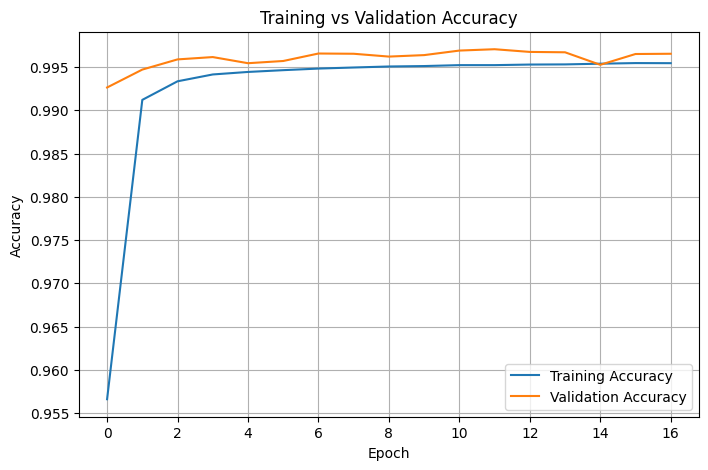

In [45]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()


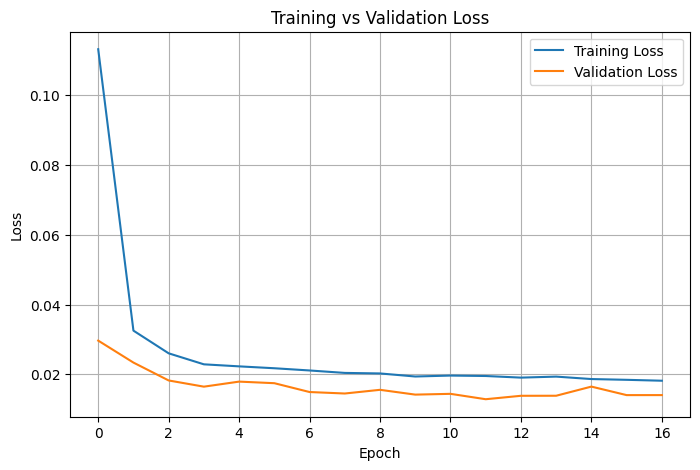

In [46]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()


In [47]:
prediction_probability = model.predict(X_test)

prediction = (

    prediction_probability >= 0.5

).astype(int)



2756/2756 ━━━━━━━━━━━━━━━━━━━━ 2s 581us/step


In [48]:
accuracy = accuracy_score(

    y_test,

    prediction

)

print(f"Model Accuracy : {accuracy:.4f}")


Model Accuracy : 0.9970


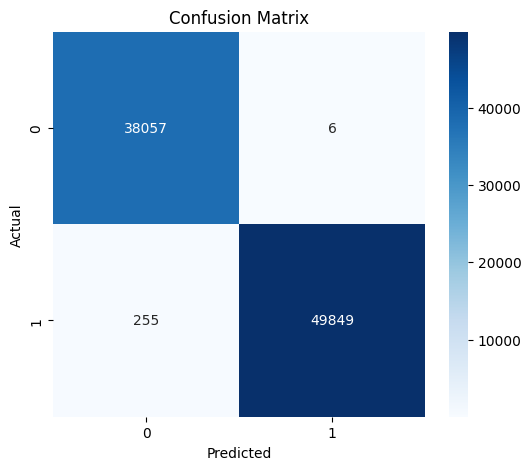

In [49]:
cm = confusion_matrix(

    y_test,

    prediction

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [50]:
print(

    classification_report(

        y_test,

        prediction

    )

)


              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     38063
         1.0       1.00      0.99      1.00     50104

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



In [51]:
auc = roc_auc_score(

    y_test,

    prediction_probability

)

print(f"ROC-AUC Score : {auc:.4f}")


ROC-AUC Score : 0.9997


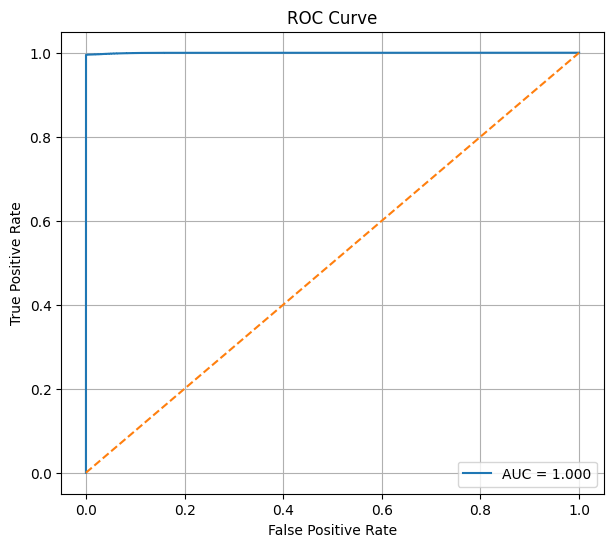

In [53]:
fpr, tpr, thresholds = roc_curve(

    y_test,

    prediction_probability

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()


In [54]:
model.save("customer_churn_ann.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [55]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully")


Scaler Saved Successfully
